Downloaded 809 rows.
Creating plot...


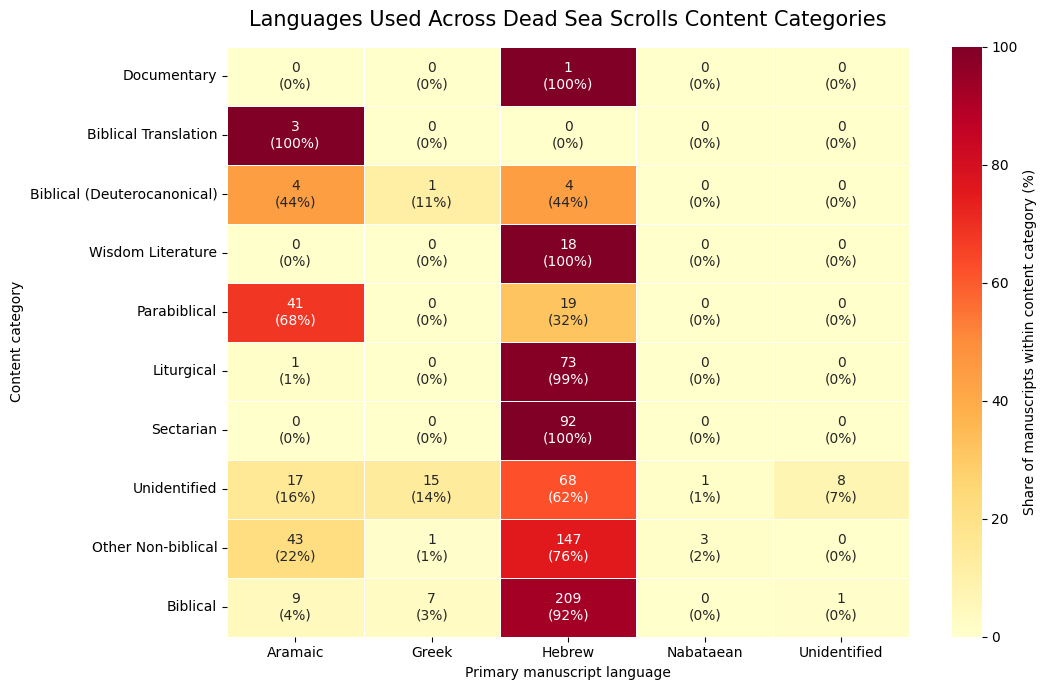

Done.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/"
    "data/2026/2026-09-15/dead_sea_scrolls.csv"
)

print("Downloading data...")

df = pd.read_csv(url)

print(f"Downloaded {len(df):,} rows.")
print("Creating plot...")

# Exclude records without usable language or content classifications
plot_df = df[
    df["language"].notna()
    & df["content_category"].notna()
    & (df["language"] != "Unknown")
].copy()

# Keep the 10 most common content categories
top_categories = (
    plot_df["content_category"]
    .value_counts()
    .head(10)
    .index
)

plot_df = plot_df[
    plot_df["content_category"].isin(top_categories)
]

# Count manuscripts by category and language
counts = pd.crosstab(
    plot_df["content_category"],
    plot_df["language"]
)

# Convert to percentages within each content category
percentages = counts.div(
    counts.sum(axis=1),
    axis=0
) * 100

# Order categories from smallest to largest
percentages = percentages.loc[
    counts.sum(axis=1).sort_values(ascending=True).index
]

# Create annotations: count + percentage
annotations = percentages.copy().astype(str)

for row in percentages.index:
    for col in percentages.columns:
        count = counts.loc[row, col]
        percentage = percentages.loc[row, col]
        annotations.loc[row, col] = f"{count}\n({percentage:.0f}%)"

# Plot
plt.figure(figsize=(11, 7))

sns.heatmap(
    percentages,
    annot=annotations,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Share of manuscripts within content category (%)"
    }
)

plt.title(
    "Languages Used Across Dead Sea Scrolls Content Categories",
    fontsize=15,
    pad=15
)

plt.xlabel("Primary manuscript language")
plt.ylabel("Content category")

plt.tight_layout()
plt.show()

print("Done.")